## Package import and dataset inspection

In [1]:
import sys, os
import argparse
import awkward
from datetime import datetime
import io
from matplotlib import pyplot as plt
import numpy as np
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
from torch_geometric.data import Data, Batch
from torch_geometric.nn import knn_graph, DynamicEdgeConv, global_mean_pool

from gnn_encoder import GNNEncoder, collate_fn_gnn
from gnn_trafo_helper import normalize_x, normalize_y, normalize_time, denormalize
#train_model, evaluate_model, , denormalize_x, denormalize_y, get_img_from_matplotlib
DATA_PATH = "./IceCube_2D_Dataset/"  # path to the data

# Load the dataset
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")


The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}
The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]
The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x =

## Normalization

In [2]:
def normalize_data(og_dataset):
    dataset = awkward.copy(og_dataset)
    norm_times=normalize_time(dataset)
    norm_x=normalize_x(dataset)
    norm_y=normalize_y(dataset)
# Concatenate the normalized data back together
    dataset["data"] = awkward.concatenate([norm_times, norm_x, norm_y], axis=1)
    # Normalize labels (this can be done in-place), e.g. by
    x_mean=awkward.mean(dataset["xpos"])
    y_mean=awkward.mean(dataset["ypos"])
    x_std=awkward.std(dataset["xpos"])
    y_std=awkward.std(dataset["ypos"])
    dataset["xpos"] = (dataset["xpos"] - x_mean) / x_std
    dataset["ypos"] = (dataset["ypos"] - y_mean) / y_std
    return dataset


norm_train_data = normalize_data(train_dataset)
norm_val_data = normalize_data(val_dataset)
norm_test_data = normalize_data(test_dataset)


In [3]:
target_x_mean = awkward.mean(train_dataset["xpos"])
target_x_std = awkward.std(train_dataset["xpos"])

target_y_mean = awkward.mean(train_dataset["ypos"])
target_y_std = awkward.std(train_dataset["ypos"])

## Data loaders

In [4]:
batch_size = 128

train_loader = DataLoader(norm_train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(norm_val_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(norm_test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)

## Network architecture

In [5]:
device = "cpu"

model = GNNEncoder(
    n_features=3,
    hidden_dim=64,
    output_dim=2,
    n_graph_layers=3,
    k=8,
).to(device)

print(model)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

GNNEncoder(
  (layer_list): ModuleList(
    (0): DynamicEdgeConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=6, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=64, bias=True)
      )
    ), k=8)
    (1-2): 2 x DynamicEdgeConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=64, bias=True)
      )
    ), k=8)
  )
  (final_mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)


## Training

In [6]:
n_epochs = 50

train_losses = []
val_losses = []

for epoch in range(n_epochs):


    model.train()

    running_loss = 0

    for step,(batch_data, labels) in enumerate(train_loader):

        batch_data = batch_data.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        pred = model(batch_data)

        loss = criterion(pred, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        # Print progress every 10th step, updating the same line
        if (step + 1) % 10 == 0:
            sys.stdout.write(f"\rEpoch [{epoch + 1}/{n_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
            sys.stdout.flush()

    sys.stdout.write("\n")  # Move to the next line after the epoch

    train_loss = (
        running_loss / len(train_loader)
    )

    train_losses.append(train_loss)

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for batch_data, labels in val_loader:
            batch_data = batch_data.to(device)
            labels = labels.to(device)

            pred = model(batch_data)

            loss = criterion(pred, labels)

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss / len(val_loader)
    )

    val_losses.append(val_loss)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}"
    )


Epoch [1/50], Step [70/79], Loss: 0.6736
Epoch 000 | Train Loss = 0.8414 | Val Loss = 0.6226
Epoch [2/50], Step [70/79], Loss: 0.5875
Epoch 001 | Train Loss = 0.5734 | Val Loss = 0.4959
Epoch [3/50], Step [70/79], Loss: 0.2387
Epoch 002 | Train Loss = 0.3352 | Val Loss = 0.2359
Epoch [4/50], Step [70/79], Loss: 0.2247
Epoch 003 | Train Loss = 0.2068 | Val Loss = 0.2021
Epoch [5/50], Step [70/79], Loss: 0.1811
Epoch 004 | Train Loss = 0.1863 | Val Loss = 0.1728
Epoch [6/50], Step [70/79], Loss: 0.1498
Epoch 005 | Train Loss = 0.1723 | Val Loss = 0.1722
Epoch [7/50], Step [70/79], Loss: 0.1528
Epoch 006 | Train Loss = 0.1616 | Val Loss = 0.1586
Epoch [8/50], Step [70/79], Loss: 0.1763
Epoch 007 | Train Loss = 0.1549 | Val Loss = 0.1627
Epoch [9/50], Step [70/79], Loss: 0.1980
Epoch 008 | Train Loss = 0.1531 | Val Loss = 0.1525
Epoch [10/50], Step [70/79], Loss: 0.1321
Epoch 009 | Train Loss = 0.1491 | Val Loss = 0.1702
Epoch [11/50], Step [70/79], Loss: 0.1476
Epoch 010 | Train Loss = 0.

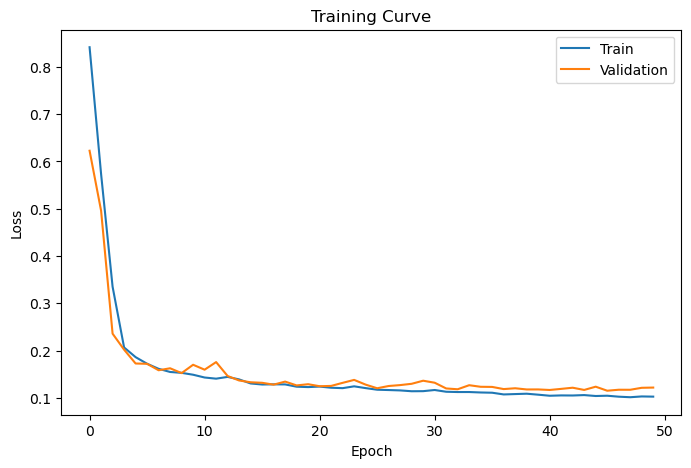

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.title("Training Curve")

plt.show()

In [8]:

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():

    for batch_data, labels in test_loader:

        batch_data = batch_data.to(device)

        pred = model(batch_data)

        pred = pred.cpu().numpy()
        labels = labels.numpy()

        all_preds.append(pred)
        all_targets.append(labels)

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

In [9]:
all_preds = denormalize(all_preds,target_x_mean,target_x_std,target_y_mean,target_y_std)
all_targets = denormalize(all_targets,target_x_mean,target_x_std,target_y_mean,target_y_std)


In [10]:
dist_error = np.sqrt(
    (all_preds[:, 0] - all_targets[:, 0])**2
    +
    (all_preds[:, 1] - all_targets[:, 1])**2
)

print(
    "Mean reconstruction error:",
    np.mean(dist_error)
)

print(
    "Median reconstruction error:",
    np.median(dist_error)
)
print(
    "Median reconstruction error for x:",
    np.median(all_targets[:,0]-all_preds[:,0])
)
print(
    "Mean reconstruction error for x:",
    np.mean(all_targets[:,0]-all_preds[:,0])
)
print(
    "Median reconstruction error for y:",
    np.median(all_targets[:,1]-all_preds[:,1])
)
print(
    "Mean reconstruction error for y:",
    np.mean(all_targets[:,1]-all_preds[:,1])
)

Mean reconstruction error: 2.0202744
Median reconstruction error: 1.7047672
Median reconstruction error for x: -0.13177443
Mean reconstruction error for x: -0.11512223
Median reconstruction error for y: 0.5602714
Mean reconstruction error for y: 0.48787576


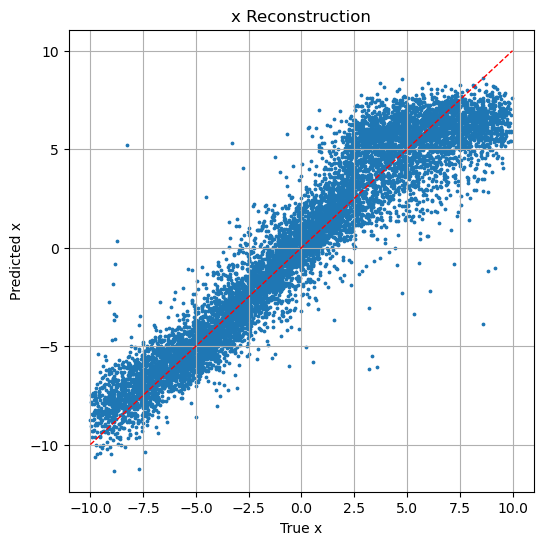

In [11]:
plt.figure(figsize=(6, 6))

plt.scatter(
    all_targets[:, 0],
    all_preds[:, 0],
    s=3,
)
plt.plot([-10, 10], [-10, 10], linestyle="--", color="red", linewidth=1)


plt.xlabel("True x")
plt.ylabel("Predicted x")

plt.title("x Reconstruction")

plt.grid()

plt.show()

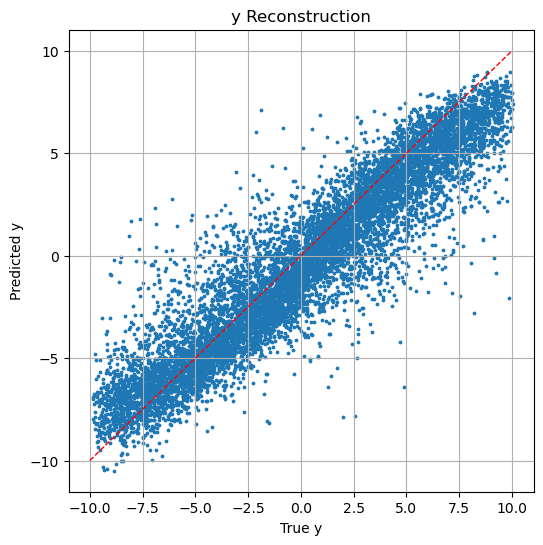

In [12]:
plt.figure(figsize=(6, 6))

plt.scatter(
    all_targets[:, 1],
    all_preds[:, 1],
    s=3,
)
plt.plot([-10, 10], [-10, 10], linestyle="--", color="red", linewidth=1)


plt.xlabel("True y")
plt.ylabel("Predicted y")

plt.title("y Reconstruction")

plt.grid()

plt.show()

Text(0, 0.5, 'Counts')

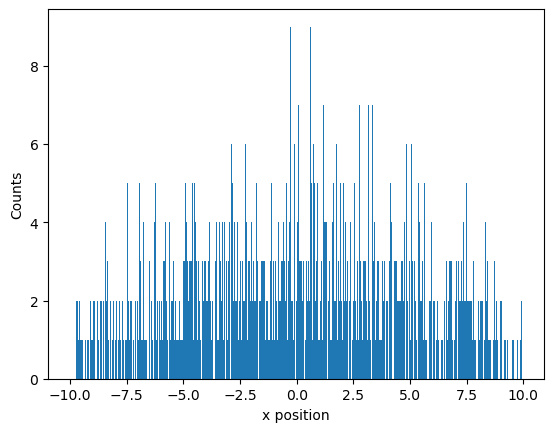

In [13]:
plt.hist(train_dataset["xpos"], bins=5000)
plt.xlabel("x position")
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

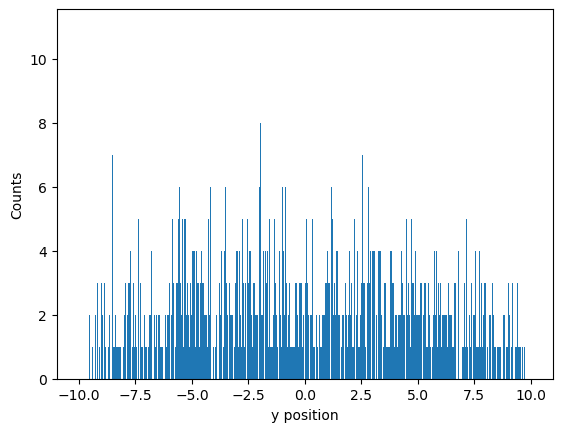

In [14]:
plt.hist(train_dataset["ypos"], bins=5000)
plt.xlabel("y position")
plt.ylabel("Counts")

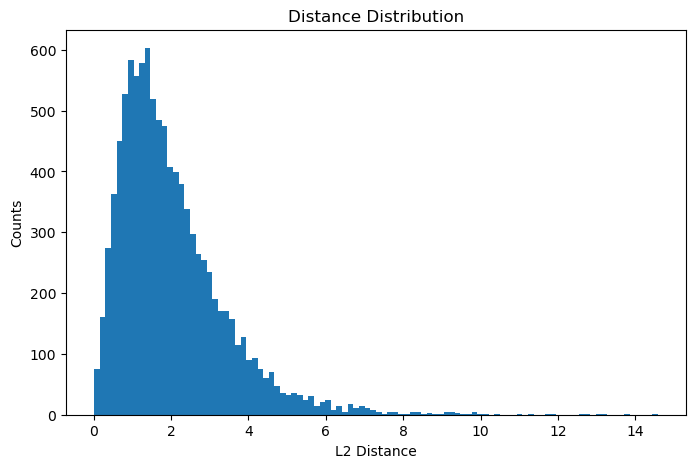

In [17]:

plt.figure(figsize=(8, 5))

plt.hist(
    dist_error,
    bins=100,
)

plt.xlabel("L2 Distance")
plt.ylabel("Counts")

plt.title("Distance Distribution")

plt.show()

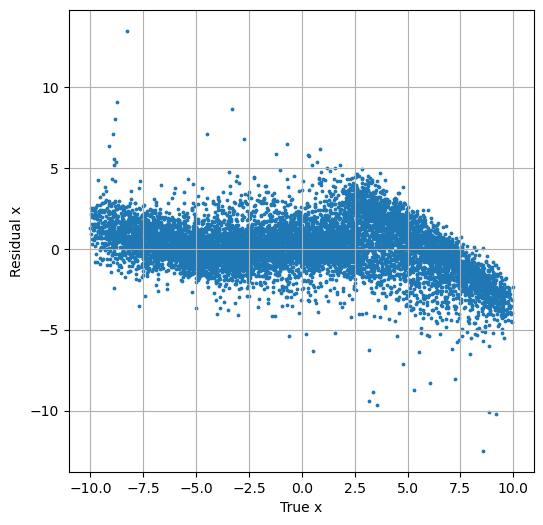

In [19]:

residual_x = (
    all_preds[:, 0]
    - all_targets[:, 0]
)
plt.figure(figsize=(6, 6))

plt.scatter(
    all_targets[:, 0],
    residual_x,
    s=3,
)


plt.xlabel("True x")
plt.ylabel("Residual x")


plt.grid()

plt.show()

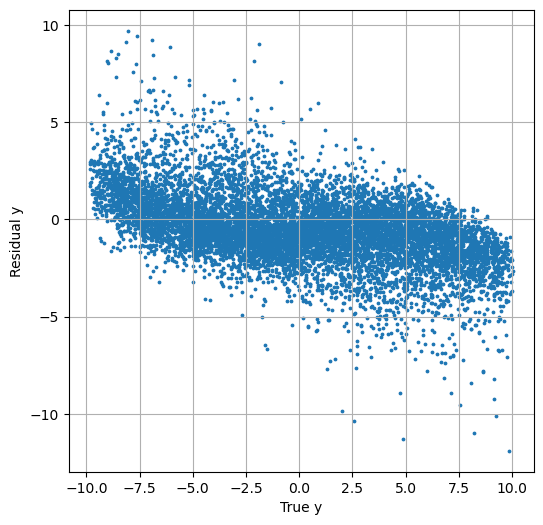

In [18]:
residual_y = (
    all_preds[:, 1]
    - all_targets[:, 1]
)


plt.figure(figsize=(6, 6))

plt.scatter(
    all_targets[:, 1],
    residual_y,
    s=3,
)


plt.xlabel("True y")
plt.ylabel("Residual y")


plt.grid()

plt.show()

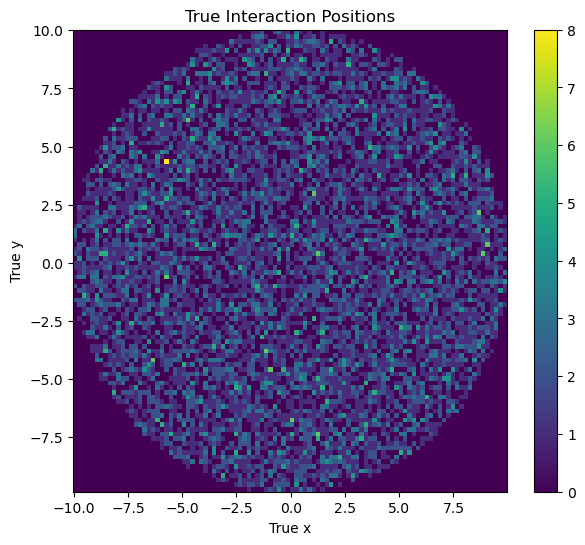

In [20]:
plt.figure(figsize=(7, 6))

plt.hist2d(
    all_targets[:, 0],
    all_targets[:, 1],
    bins=100,
)

plt.xlabel("True x")
plt.ylabel("True y")

plt.title("True Interaction Positions")

plt.colorbar()

plt.show()

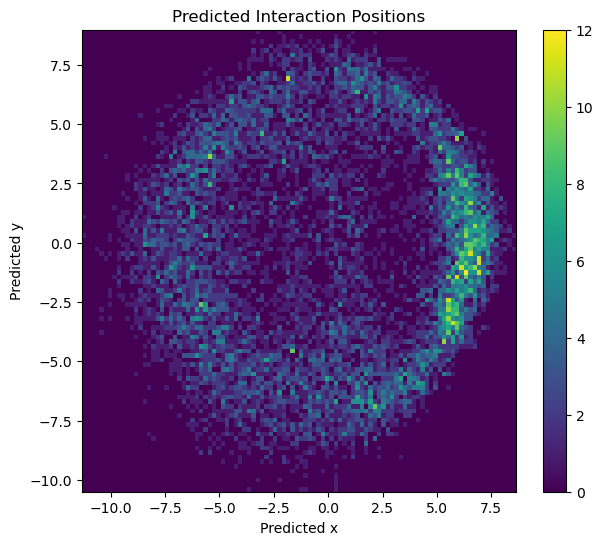

In [21]:
plt.figure(figsize=(7, 6))

plt.hist2d(
    all_preds[:, 0],
    all_preds[:, 1],
    bins=100,
)

plt.xlabel("Predicted x")
plt.ylabel("Predicted y")

plt.title("Predicted Interaction Positions")

plt.colorbar()

plt.show()

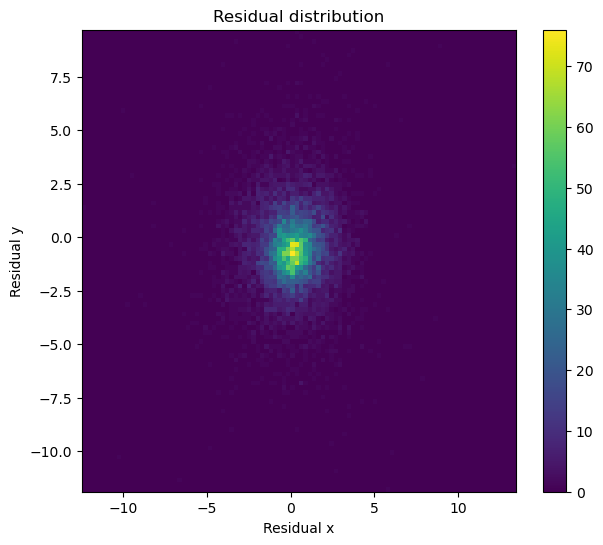

In [22]:
plt.figure(figsize=(7, 6))

plt.hist2d(
    residual_x,
    residual_y,
    bins=100,
)

plt.xlabel("Residual x")
plt.ylabel("Residual y")

plt.title("Residual distribution")

plt.colorbar()

plt.show()

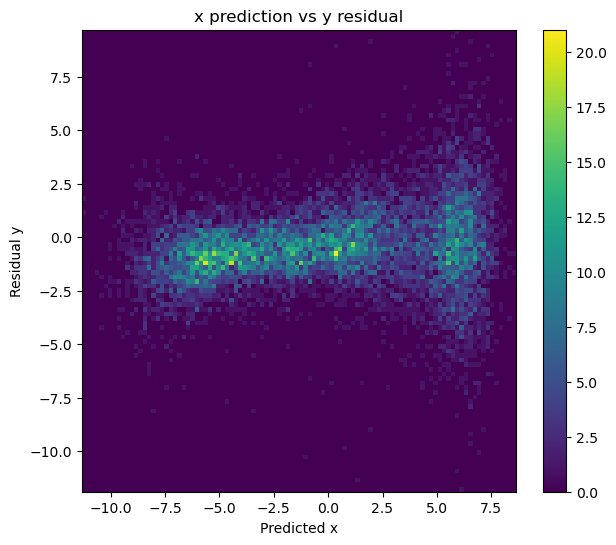

In [23]:
plt.figure(figsize=(7, 6))

plt.hist2d(
    all_preds[:,0],
    residual_y,
    bins=100,
)

plt.xlabel("Predicted x")
plt.ylabel("Residual y")

plt.title("x prediction vs y residual")

plt.colorbar()

plt.show()

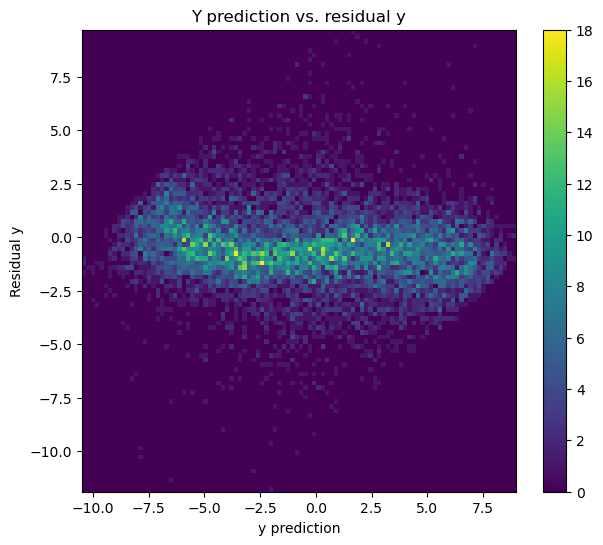

In [24]:
plt.figure(figsize=(7, 6))

plt.hist2d(
    all_preds[:,1],
    residual_y,
    bins=100,
)

plt.xlabel("y prediction")
plt.ylabel("Residual y")

plt.title("Y prediction vs. residual y")

plt.colorbar()

plt.show()

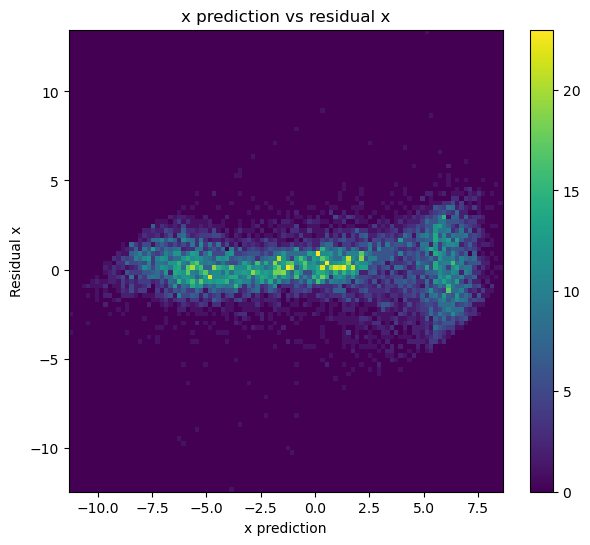

In [25]:
plt.figure(figsize=(7, 6))

plt.hist2d(
    all_preds[:,0],
    residual_x,
    bins=100,
)

plt.xlabel("x prediction")
plt.ylabel("Residual x")

plt.title("x prediction vs residual x")

plt.colorbar()

plt.show()

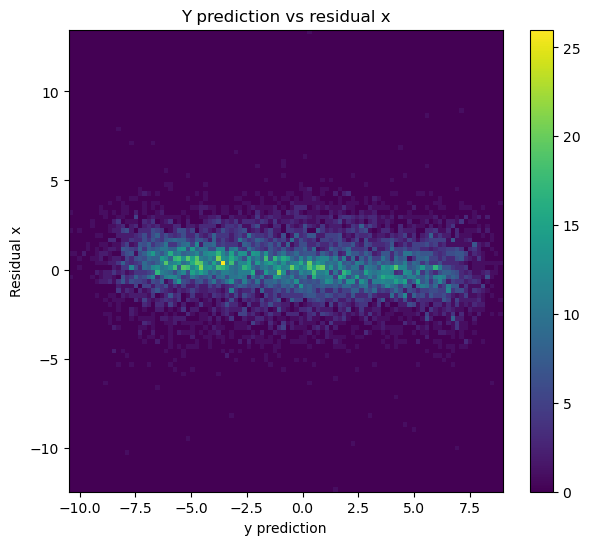

In [26]:
plt.figure(figsize=(7, 6))

plt.hist2d(
    all_preds[:,1],
    residual_x,
    bins=100,
)

plt.xlabel("y prediction")
plt.ylabel("Residual x")

plt.title("Y prediction vs residual x")

plt.colorbar()

plt.show()